# CNN Image Classification — Fashion MNIST

We train a Keras `Sequential` CNN (`Conv2D` + `MaxPooling2D` stack) on `tf.keras.datasets.fashion_mnist`, a built-in dataset of 10 classes of clothing items in $28\times28$ grayscale images. This demonstrates the convolution/pooling/flatten pipeline described in `notes.md`.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

print('TF version:', tf.__version__)

I0000 00:00:1787472071.562453   25049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472071.562826   25049 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1787472071.601343   25049 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1787472072.424895   25049 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1787472072.425185   25049 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


TF version: 2.21.0


## Load Fashion MNIST

In [2]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

X_train, X_val = X_train_full[:-6000], X_train_full[-6000:]
y_train, y_val = y_train_full[:-6000], y_train_full[-6000:]

print('Train:', X_train.shape, 'Val:', X_val.shape, 'Test:', X_test.shape)

    0/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

16384/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 4us/step

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 3us/step


       0/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

   16384/26421880 ━━━━━━━━━━━━━━━━━━━━ 3:49 9us/step

...

4276224/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

4341760/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

4399104/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step

4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 5s 1us/step


Train: (54000, 28, 28) Val: (6000, 28, 28) Test: (10000, 28, 28)


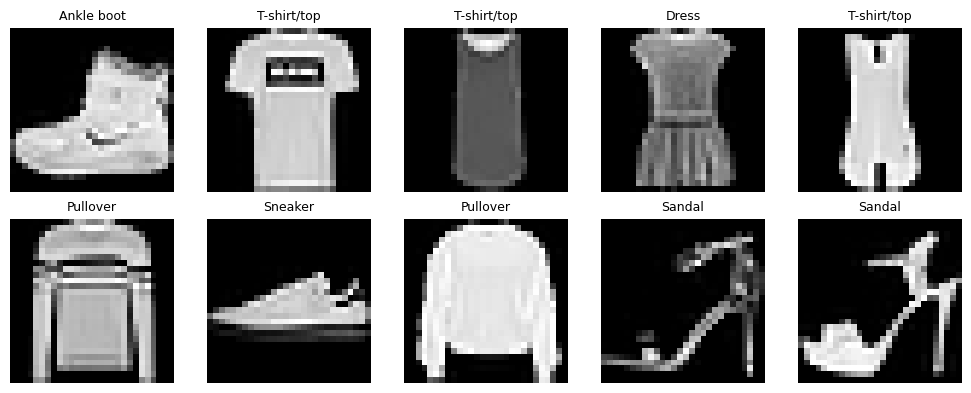

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i], cmap='gray')
    ax.set_title(class_names[y_train[i]], fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Preprocess

Normalize pixel values to $[0, 1]$ and add a channel dimension so images have shape `(28, 28, 1)` as expected by `Conv2D`.

In [4]:
X_train = X_train.astype('float32') / 255.0
X_val = X_val.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]
X_test = X_test[..., np.newaxis]

print(X_train.shape, X_val.shape, X_test.shape)

(54000, 28, 28, 1) (6000, 28, 28, 1) (10000, 28, 28, 1)


## Build the CNN

Two `Conv2D` + `MaxPooling2D` blocks extract spatial features, then `Flatten` and `Dense` layers classify into 10 clothing categories via softmax.

In [5]:
model = keras.Sequential([
    layers.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
    layers.MaxPooling2D(pool_size=2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax'),
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.summary()

E0000 00:00:1787472103.754023   25049 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1787472103.754386   25202 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1787472103.778111   25049 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │       200,768 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 220,234 (860.29 KB)

 Trainable params: 220,234 (860.29 KB)

 Non-trainable params: 0 (0.00 B)

In [6]:
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss', patience=3, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10, batch_size=64,
    callbacks=[early_stop], verbose=2)

Epoch 1/10


844/844 - 8s - 10ms/step - accuracy: 0.8040 - loss: 0.5445 - val_accuracy: 0.8712 - val_loss: 0.3492


Epoch 2/10


844/844 - 7s - 9ms/step - accuracy: 0.8712 - loss: 0.3603 - val_accuracy: 0.8842 - val_loss: 0.3039


Epoch 3/10


...

844/844 - 7s - 9ms/step - accuracy: 0.9238 - loss: 0.2037 - val_accuracy: 0.9157 - val_loss: 0.2351


Epoch 9/10


844/844 - 8s - 9ms/step - accuracy: 0.9294 - loss: 0.1887 - val_accuracy: 0.9208 - val_loss: 0.2308


Epoch 10/10


844/844 - 8s - 9ms/step - accuracy: 0.9349 - loss: 0.1760 - val_accuracy: 0.9175 - val_loss: 0.2343


## Training curves

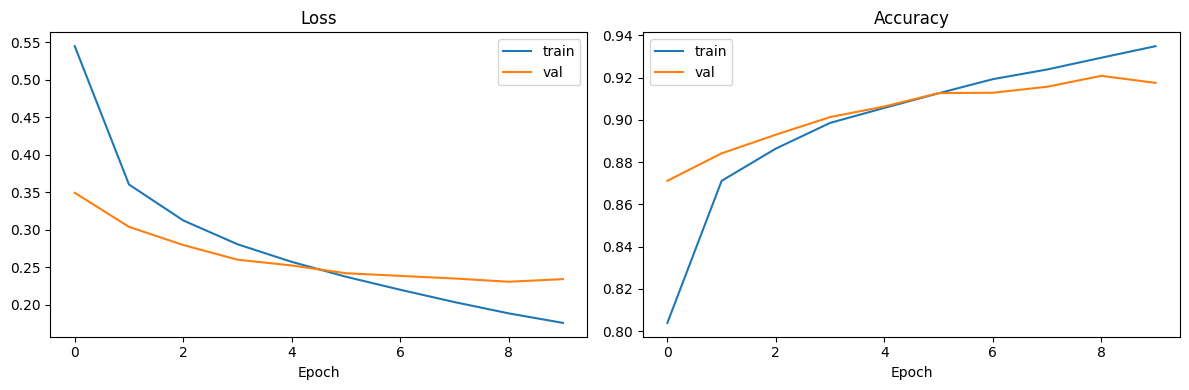

In [7]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(history.history['loss'], label='train')
ax[0].plot(history.history['val_loss'], label='val')
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend()

ax[1].plot(history.history['accuracy'], label='train')
ax[1].plot(history.history['val_accuracy'], label='val')
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend()
plt.tight_layout()
plt.show()

## Evaluate on the test set

In [8]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f'Test accuracy: {test_acc:.4f}')
print(f'Test loss:     {test_loss:.4f}')

Test accuracy: 0.9143
Test loss:     0.2552


## Sample predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step


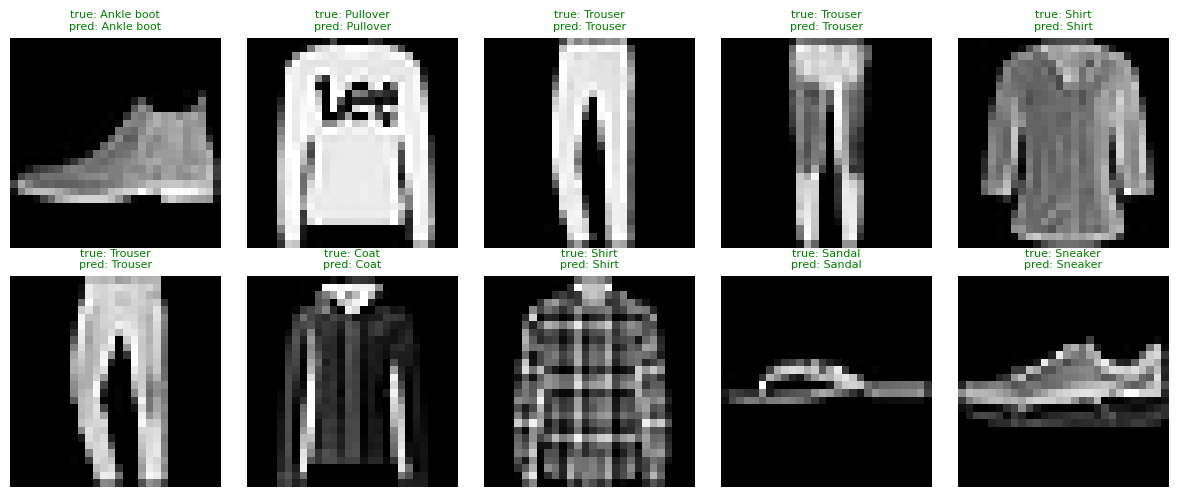

In [9]:
probs = model.predict(X_test[:10])
preds = np.argmax(probs, axis=1)

fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].squeeze(), cmap='gray')
    true_lbl = class_names[y_test[i]]
    pred_lbl = class_names[preds[i]]
    color = 'green' if preds[i] == y_test[i] else 'red'
    ax.set_title(f'true: {true_lbl}\npred: {pred_lbl}', fontsize=8, color=color)
    ax.axis('off')
plt.tight_layout()
plt.show()

## Summary

A compact 2-block CNN comfortably beats what a plain ANN could achieve at similar parameter budget on Fashion MNIST, illustrating parameter sharing and translation invariance from `notes.md`.